In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import pandas as pd
from scipy.stats import linregress, theilslopes
import sys

# --- PATH SETUP ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# --- LOCAL IMPORTS ---
%load_ext autoreload
%autoreload 2
from src.analysis import processing as proc
from src.analysis import plotting as viz

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded.")

Libraries loaded.


In [6]:
def calculate_box_counts(coords):
    """
    Returns the raw (box_size, count) arrays for a given cluster.
    """
    max_box_size = int(np.max(np.abs(coords))) + 1
    
    # Define scales: Powers of 2 from 8 up to R/16 
    upper_limit = max_box_size / 16
    scales = np.logspace(3, np.log2(upper_limit), num=50, base=2, dtype=int)
    scales = np.unique(scales) # Remove duplicates
    scales = scales[scales >= 2] # Remove tiny boxes < 2px

    counts = []
    
    y_multiplier = int(max_box_size * 2 + 10000)
    coords_pos = coords + max_box_size # Shift to positive

    for eps in scales:
        grid_x = np.floor(coords_pos[:,0] / eps).astype(np.int64)
        grid_y = np.floor(coords_pos[:,1] / eps).astype(np.int64)
        grid_hash = grid_x + (grid_y * y_multiplier)
        unique_count = len(np.unique(grid_hash))
        counts.append(unique_count)
    
    return scales, np.array(counts)


In [4]:
# --- LOAD ONE CLUSTER PER MODEL/SIZE ---
samples = {}
models = ['Lattice', 'OffLattice', 'Hybrid'] 
sizes = ['1M', '10M']

print(f"Searching for data in: {os.path.join(project_root, 'results', 'analysis_clusters')}")

for model in models:
    for size in sizes:
        base_dir = os.path.join(project_root, 'results', 'analysis_clusters', model, size)
        search_pattern = os.path.join(base_dir, "*.npz")
        
        # finds all files matching the pattern
        files = glob.glob(search_pattern)
        
        if len(files) > 0:
            # picks the first file found (random seed)
            target_file = files[0]
            try:
                coords = proc.load_cluster(target_file)
                samples[f"{model}_{size}"] = coords
                print(f"✅ Loaded {model}_{size}: {coords.shape} (File: {os.path.basename(target_file)})")
                
            except Exception as e:
                print(f" Error loading {model}_{size}: {e}")
        else:
            print(f" No files found for {model}/{size}")


Searching for data in: /Users/ramsaydavis/dla/results/analysis_clusters
✅ Loaded Lattice_1M: (1000000, 2) (File: 77.npz)
✅ Loaded Lattice_10M: (10000000, 2) (File: 10043.npz)
✅ Loaded OffLattice_1M: (1000001, 2) (File: 1409.npz)
✅ Loaded OffLattice_10M: (10000001, 2) (File: 10137.npz)
✅ Loaded Hybrid_1M: (1000001, 2) (File: 2672.npz)
✅ Loaded Hybrid_10M: (10000001, 2) (File: 10241.npz)


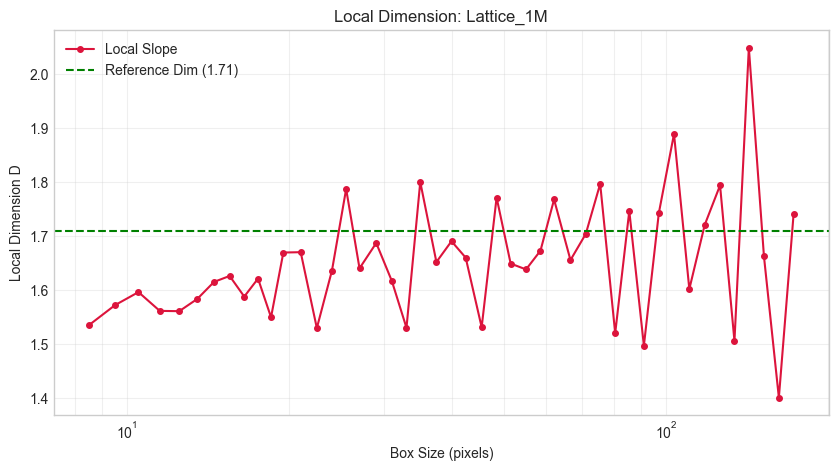

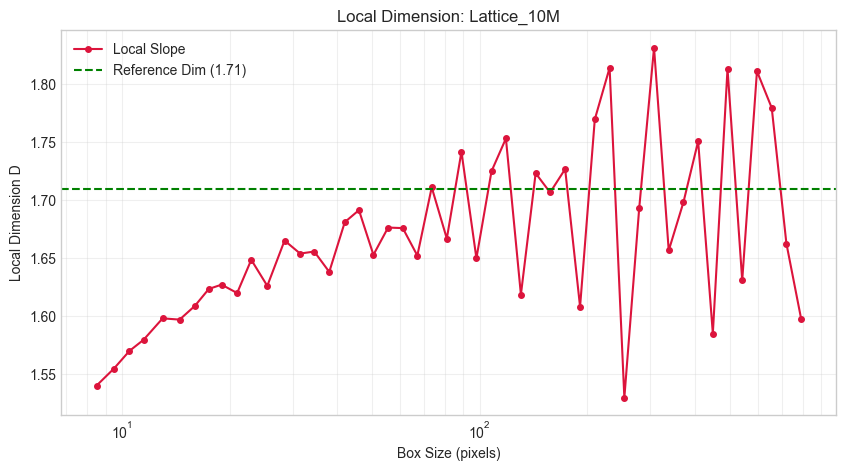

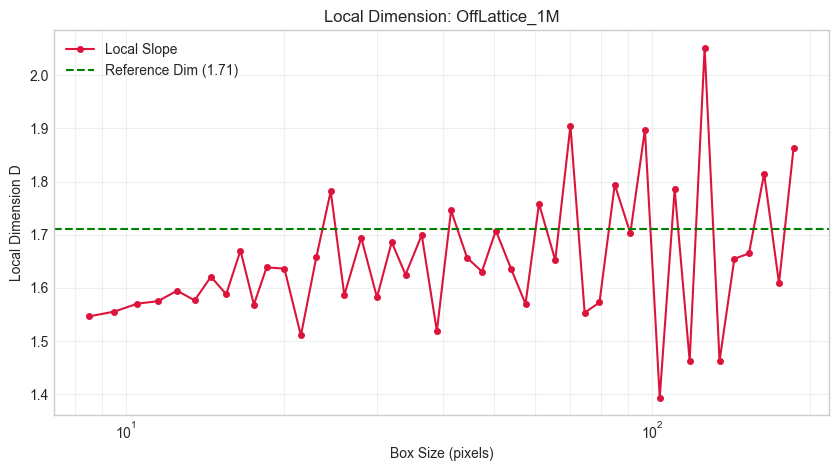

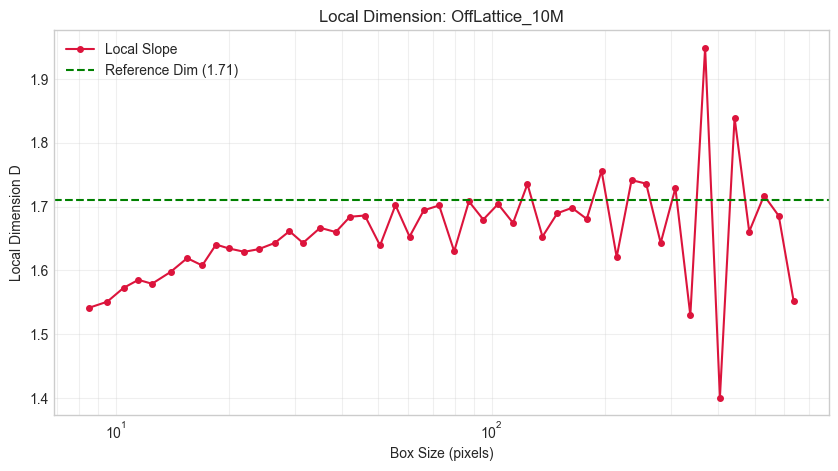

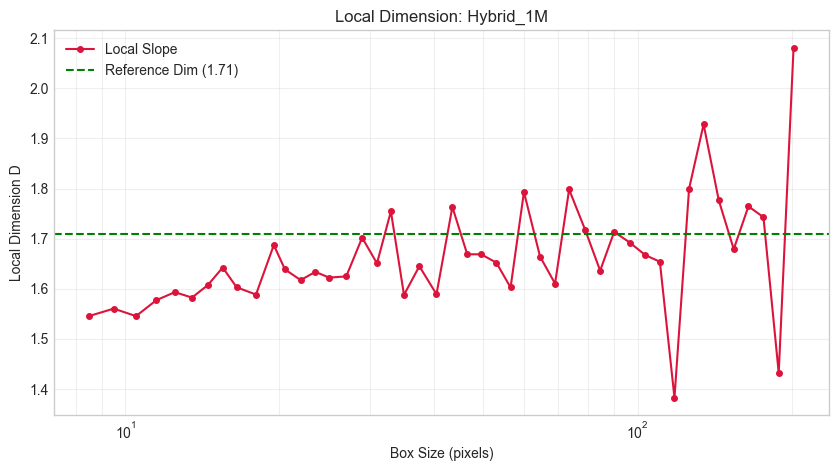

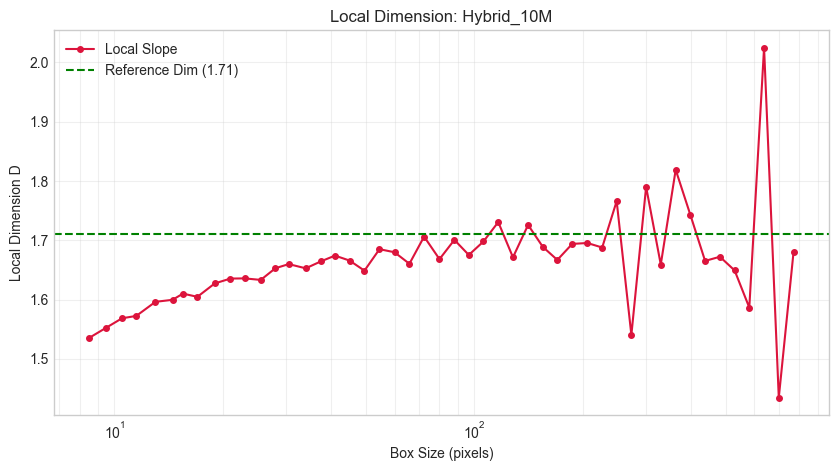

In [7]:
def plot_local_dimension(coords, title="Local Dimension Analysis"):
    scales, counts = calculate_box_counts(coords)
    
    log_eps = np.log(scales)
    log_N = np.log(counts)
    
    # Derivative: d(log N) / d(log eps)
    # use central difference for smoother derivative
    local_dim = -np.diff(log_N) / np.diff(log_eps) 
    mid_points = (scales[:-1] + scales[1:]) / 2
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(mid_points, local_dim, 'o-', color='crimson', markersize=4, label='Local Slope')
    
    # Reference Lines
    ax.axhline(1.71, color='green', linestyle='--', label='Reference Dim (1.71)')
    
    ax.set_xscale('log')
    ax.set_xlabel('Box Size (pixels)')
    ax.set_ylabel('Local Dimension D')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    
    return mid_points, local_dim

# Run on clusters 
for name, coords in samples.items():
    plot_local_dimension(coords, title=f"Local Dimension: {name}")
    plt.show() # Ensure each plot renders


--- Lattice_1M ---
Standard Fit (L2):      1.6568
Robust Fit (Theil-Sen): 1.6595
Uncertainty Cone:       0.0131


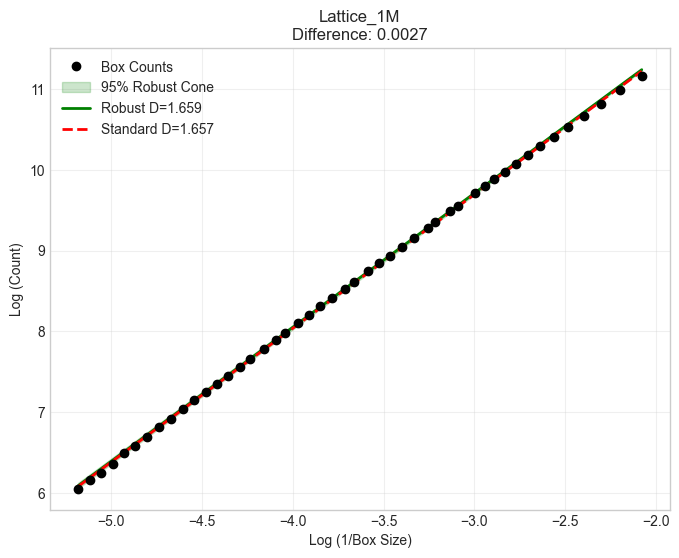

--- Lattice_10M ---
Standard Fit (L2):      1.6766
Robust Fit (Theil-Sen): 1.6815
Uncertainty Cone:       0.0142


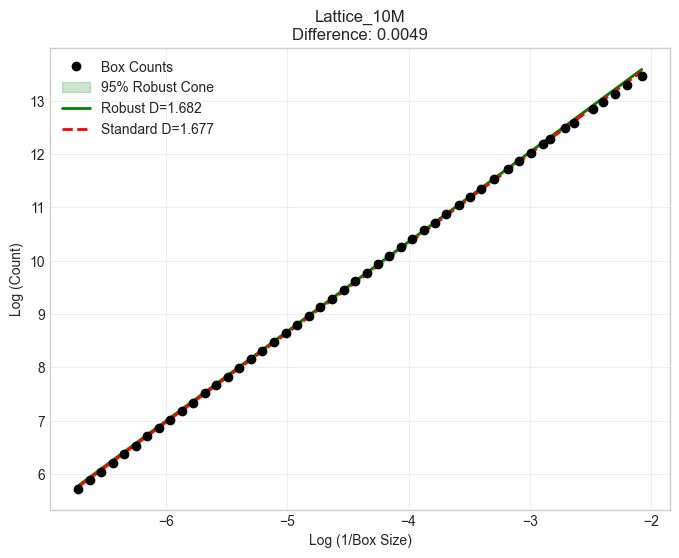

--- OffLattice_1M ---
Standard Fit (L2):      1.6535
Robust Fit (Theil-Sen): 1.6568
Uncertainty Cone:       0.0128


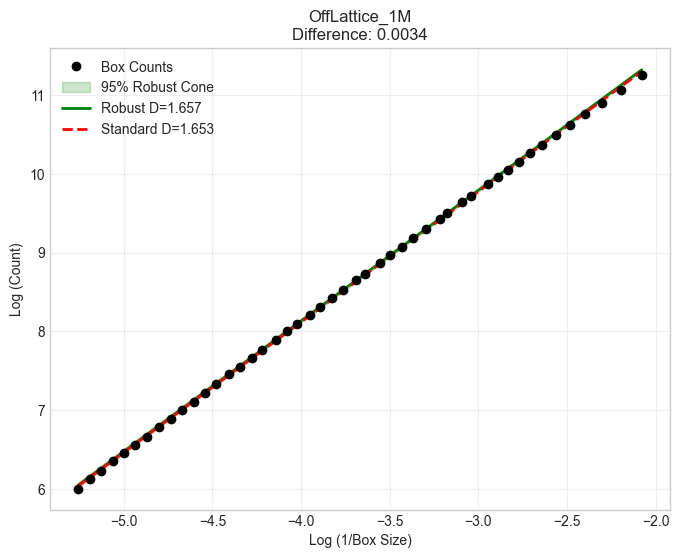

--- OffLattice_10M ---
Standard Fit (L2):      1.6692
Robust Fit (Theil-Sen): 1.6752
Uncertainty Cone:       0.0111


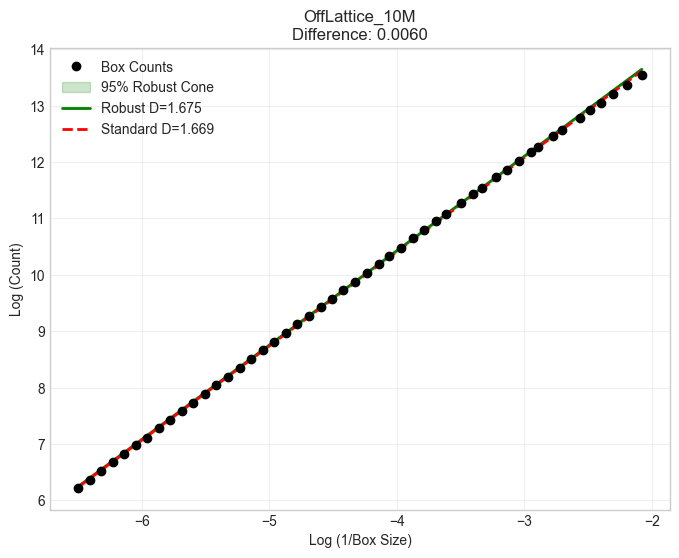

--- Hybrid_1M ---
Standard Fit (L2):      1.6606
Robust Fit (Theil-Sen): 1.6636
Uncertainty Cone:       0.0145


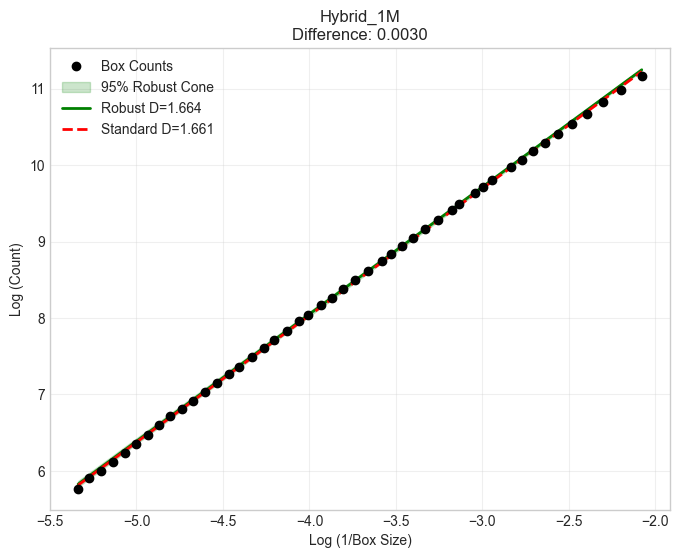

--- Hybrid_10M ---
Standard Fit (L2):      1.6731
Robust Fit (Theil-Sen): 1.6782
Uncertainty Cone:       0.0130


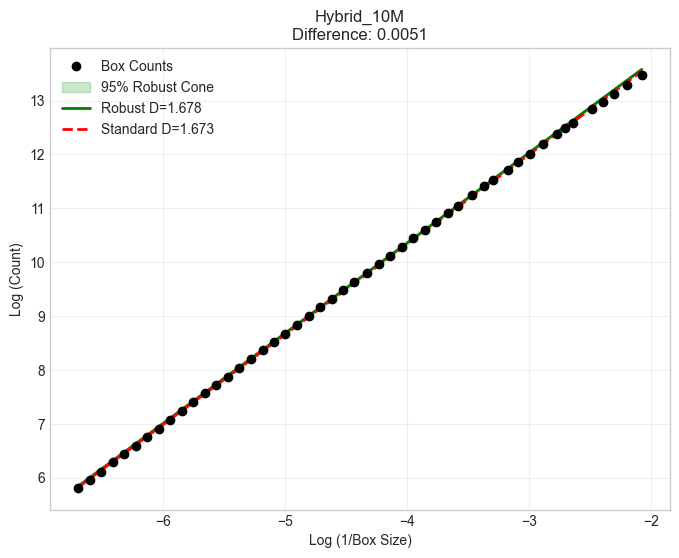

In [8]:
def analyse_slope_robustness(coords, title="Regression Robustness"):
    # raw box-counting data
    scales, counts = calculate_box_counts(coords)
    
    # Log-Log Transformation
    x = np.log(1 / scales)
    y = np.log(counts)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # standard regression
    res = linregress(x, y)
    D_l2 = res.slope  # Slope is D
    
    # using theil-sen
    # returns median_slope, intercept, lower_bound_slope, upper_bound_slope
    slope_ts, intercept_ts, low_slope, high_slope = theilslopes(y, x, 0.95)
    D_robust = slope_ts
    
    # Plot Data
    ax.plot(x, y, 'ko', label='Box Counts', zorder=3)
    
    # Define Range for lines
    x_range = np.array([min(x), max(x)])
    
    # Plot 95% Confidence Interval of Slope
    y_low = intercept_ts + low_slope * x_range
    y_high = intercept_ts + high_slope * x_range
    ax.fill_between(x_range, y_low, y_high, color='green', alpha=0.2, label='95% Robust Cone')
    
    # Plot The Fits
    ax.plot(x_range, intercept_ts + slope_ts * x_range, 'g-', linewidth=2, label=f'Robust D={D_robust:.3f}')
    ax.plot(x_range, res.intercept + res.slope * x_range, 'r--', linewidth=2, label=f'Standard D={D_l2:.3f}')
    
    # Formatting
    ax.set_xlabel("Log (1/Box Size)")
    ax.set_ylabel("Log (Count)")
    ax.set_title(f"{title}\nDifference: {abs(D_l2 - D_robust):.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    print(f"--- {title} ---")
    print(f"Standard Fit (L2):      {D_l2:.4f}")
    print(f"Robust Fit (Theil-Sen): {D_robust:.4f}")
    print(f"Uncertainty Cone:       {high_slope - low_slope:.4f}")
    
    return D_l2, D_robust

# run on samples
for name, coords in samples.items():
    analyse_slope_robustness(coords, title=name)
    plt.show()

Analyzing convergence for Lattice (1000 files loaded)...


/var/folders/4t/j6s0_pjn51gcp0q2x317m5n40000gn/T/ipykernel_34693/1113861666.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


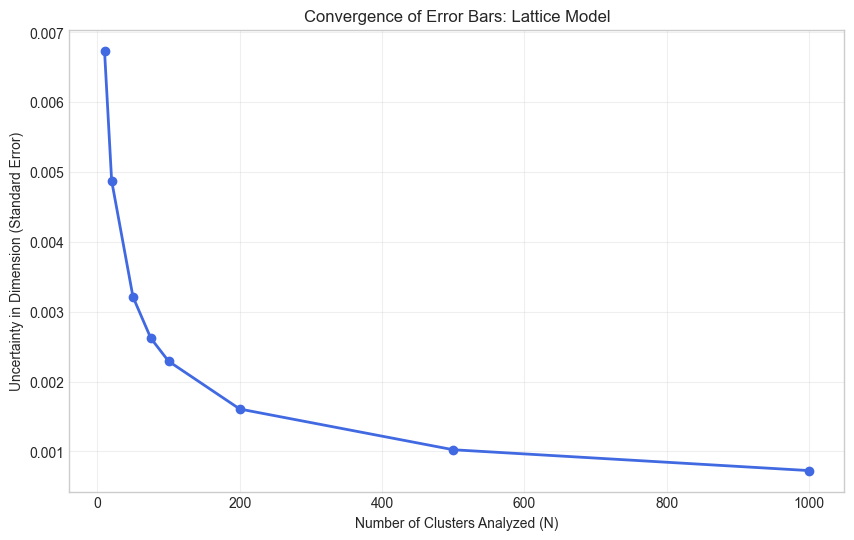

Analyzing convergence for Lattice (100 files loaded)...


/var/folders/4t/j6s0_pjn51gcp0q2x317m5n40000gn/T/ipykernel_34693/1113861666.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


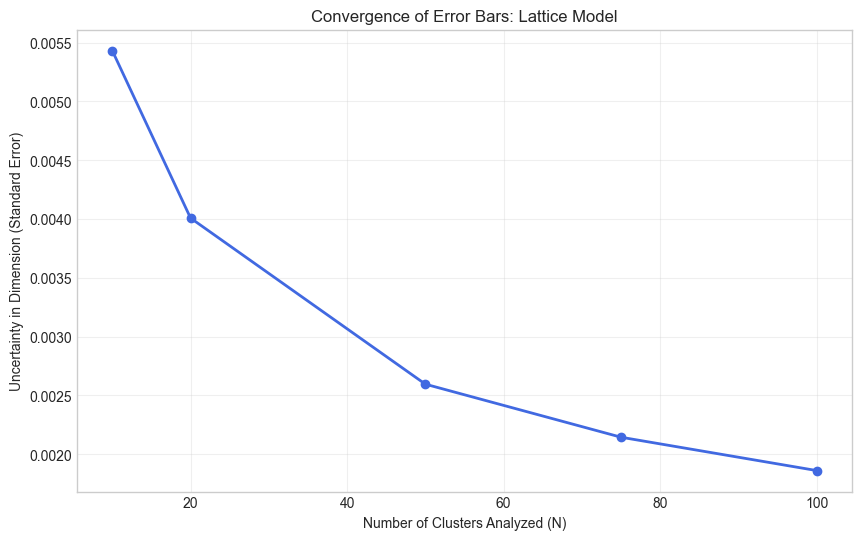

In [13]:

def plot_convergence_real(model_name="Lattice", size_label="1M"):
    """
    Loads real scalar data and plots how the Standard Error of D shrinks with N.
    """
    file_path = f"../results/processed/{model_name}_{size_label}_scalars.csv"
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    df = pd.read_csv(file_path)
    
    # 2. Convert to Dimension (D = 1/beta)
    # We filter out any failed runs (NaNs)
    valid_betas = df['beta'].dropna()
    all_dims = 1.0 / valid_betas.values
    
    total_files = len(all_dims)
    print(f"Analyzing convergence for {model_name} ({total_files} files loaded)...")
    
    # Define Sample Sizes to Test
    sample_sizes = [10, 20, 50, 75, 100, 200, 500, 1000]
    sample_sizes = [n for n in sample_sizes if n <= total_files]
    
    std_errors = []
    
    # 4. Bootstrap Loop
    for n in sample_sizes:
        # We repeat sampling 100 times to smooth out  curve
        bootstrap_errors = []
        for _ in range(100):
            subset = np.random.choice(all_dims, size=n, replace=False)
            
            # Calculate Standard Error
            sem = np.std(subset) / np.sqrt(n)
            bootstrap_errors.append(sem)
            
        # Average the error for this sample size
        std_errors.append(np.mean(bootstrap_errors))
        
    # 5. Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(sample_sizes, std_errors, 'o-', linewidth=2, color='royalblue')

    plt.xlabel("Number of Clusters Analyzed (N)")
    plt.ylabel("Uncertainty in Dimension (Standard Error)")
    plt.title(f"Convergence of Error Bars: {model_name} Model")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    
    
    plt.show()

# --- EXECUTION ---
# Use your most "standard" model to prove the statistics
plot_convergence_real("Lattice", "1M") 
plot_convergence_real("Lattice",'10M')

--- Lattice Statistics ---
1M  Growth Mean: 1.6781 | Box Mean: 1.6565
10M Growth Mean: 1.6427 | Box Mean: 1.6723


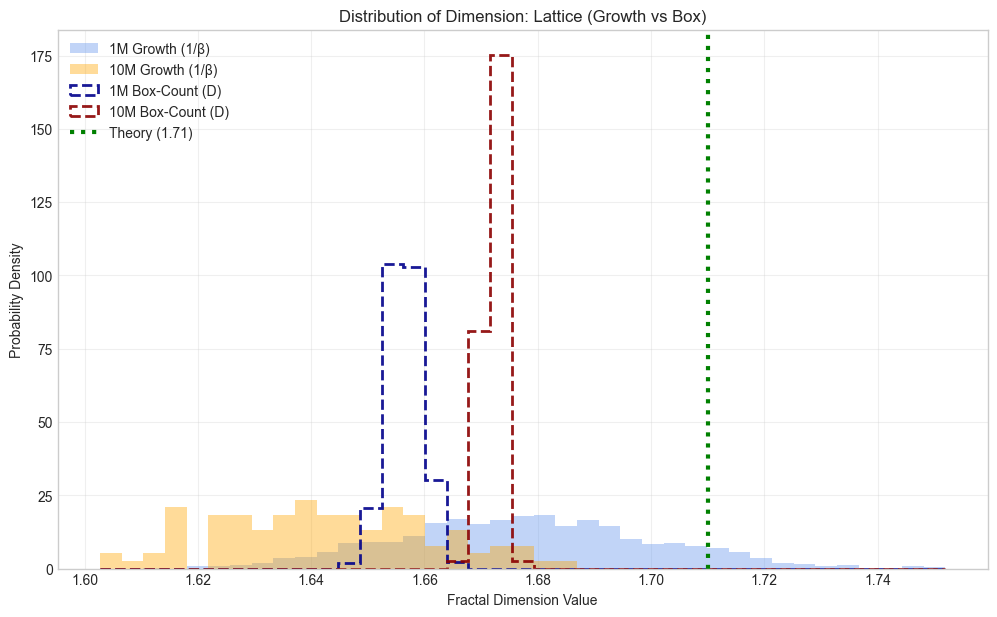

--- OffLattice Statistics ---
1M  Growth Mean: 1.7134 | Box Mean: 1.6514
10M Growth Mean: 1.7120 | Box Mean: 1.6684


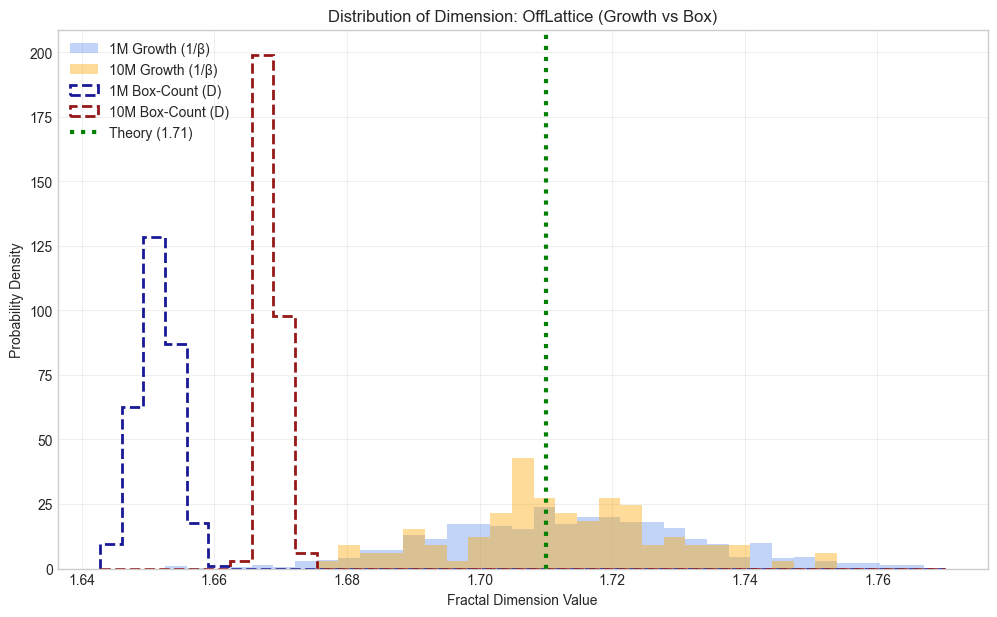

--- Hybrid Statistics ---
1M  Growth Mean: 1.6708 | Box Mean: 1.6559
10M Growth Mean: 1.6339 | Box Mean: 1.6718


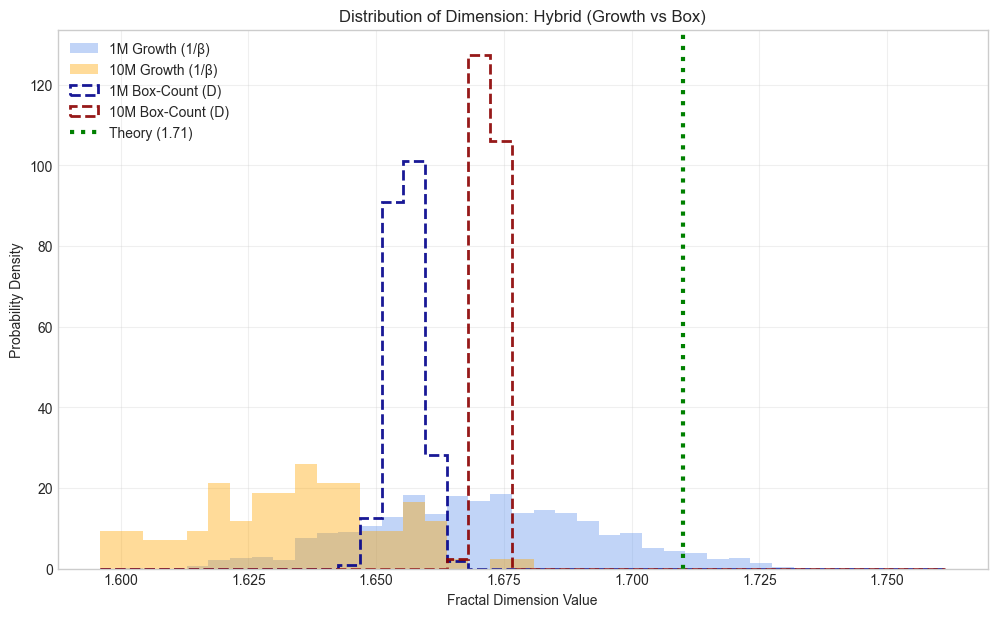

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def compare_evolution_full_density(model_name="Lattice"):
    """
    Plots 4 overlayed histograms using PROBABILITY DENSITY:
    1. 1M Growth Dimension (1/beta)
    2. 10M Growth Dimension (1/beta)
    3. 1M Box-Counting Dimension (D)
    4. 10M Box-Counting Dimension (D)
    """
    # 1. Define Paths
    path_1m = f"../results/processed/{model_name}_1M_scalars.csv"
    path_10m = f"../results/processed/{model_name}_10M_scalars.csv"
    
    # 2. Check existence
    if not os.path.exists(path_1m) or not os.path.exists(path_10m):
        print(f"Skipping {model_name}: Data files not found.")
        return

    # 3. Load Data
    df_1m = pd.read_csv(path_1m)
    df_10m = pd.read_csv(path_10m)
    
    # 4. Extract Data & Handle NaNs
    
    # --- Growth Dimension (1/beta) ---
    beta_1m = df_1m['beta'].dropna()
    d_growth_1m = 1.0 / beta_1m[beta_1m > 0]
    
    beta_10m = df_10m['beta'].dropna()
    d_growth_10m = 1.0 / beta_10m[beta_10m > 0]
    
    # --- Box-Counting Dimension (D) ---
    if 'D' in df_1m.columns:
        d_box_1m = df_1m['D'].dropna()
        d_box_1m = d_box_1m[d_box_1m > 0] 
    else:
        d_box_1m = []
        print("Warning: 'D' column not found in 1M data")

    if 'D' in df_10m.columns:
        d_box_10m = df_10m['D'].dropna()
        d_box_10m = d_box_10m[d_box_10m > 0]
    else:
        d_box_10m = []
        print("Warning: 'D' column not found in 10M data")
    
    print(f"--- {model_name} Statistics ---")
    print(f"1M  Growth Mean: {np.mean(d_growth_1m):.4f} | Box Mean: {np.mean(d_box_1m):.4f}")
    print(f"10M Growth Mean: {np.mean(d_growth_10m):.4f} | Box Mean: {np.mean(d_box_10m):.4f}")
    
    plt.figure(figsize=(12, 7))
    

    all_data = np.concatenate([d_growth_1m, d_growth_10m, d_box_1m, d_box_10m])
    bins = np.linspace(np.min(all_data), np.max(all_data), 40)
    
    # --- PLOT GROWTH DIMENSIONS (Solid Colors) ---
    # 1M Growth (Blue, Solid)
    plt.hist(d_growth_1m, bins=bins, alpha=0.4, density=True, 
             label=f'1M Growth (1/β)', color='cornflowerblue', edgecolor='none')
    
    # 10M Growth (Orange, Solid)
    plt.hist(d_growth_10m, bins=bins, alpha=0.4, density=True,
             label=f'10M Growth (1/β)', color='orange', edgecolor='none')

    # --- PLOT BOX DIMENSIONS (Hatched/Step) ---
    # 1M Box (Blue, Hatched/Line)
    plt.hist(d_box_1m, bins=bins, alpha=0.9, density=True,     
             histtype='step', linewidth=2,
             label=f'1M Box-Count (D)', color='darkblue', linestyle='--')
    
    # 10M Box (Orange, Hatched/Line)
    plt.hist(d_box_10m, bins=bins, alpha=0.9, density=True,   
             histtype='step', linewidth=2,
             label=f'10M Box-Count (D)', color='darkred', linestyle='--')
    
    # --- Reference Lines ---
    plt.axvline(1.71, color='green', linestyle=':', linewidth=3, label='Theory (1.71)')
    
    # Formatting
    plt.xlabel("Fractal Dimension Value")
    plt.ylabel("Probability Density") # <--- UPDATED LABEL
    plt.title(f"Distribution of Dimension: {model_name} (Growth vs Box)")
    plt.legend(loc='upper left', framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.show()

# --- EXECUTION ---
compare_evolution_full_density("Lattice")
compare_evolution_full_density("OffLattice")
compare_evolution_full_density("Hybrid")

Some CHATGPT generated plots (not particuallry useful atm, but will keep jic)

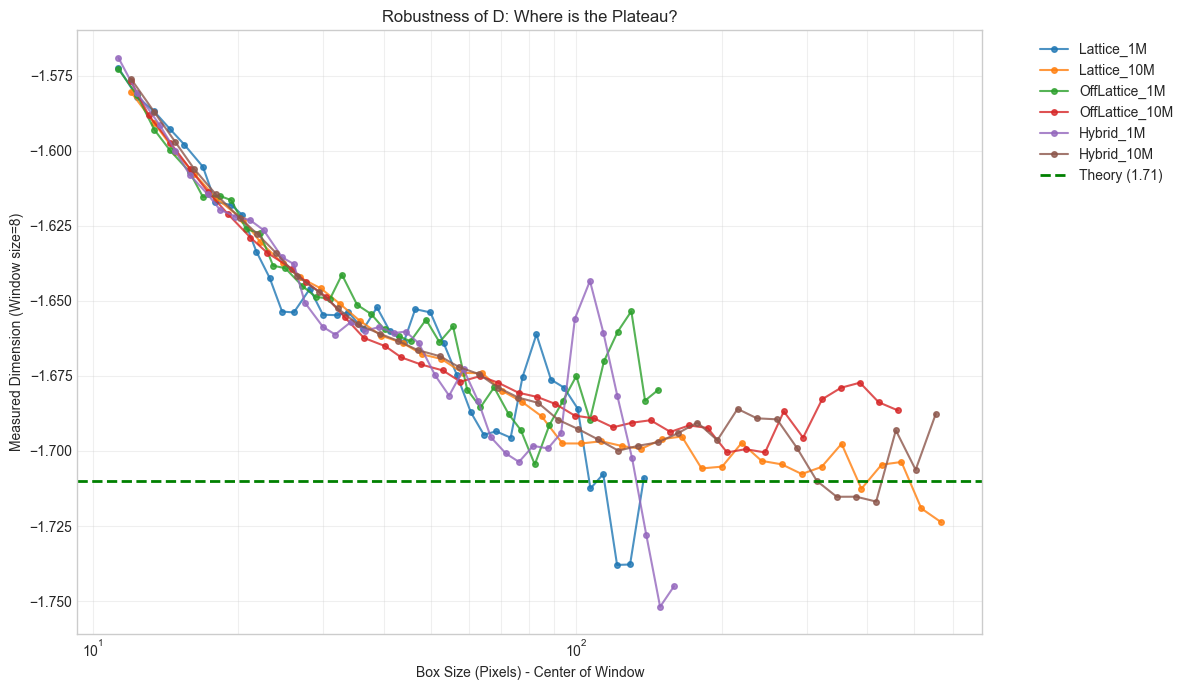

In [11]:
def cutoff_sensitivity_multi(samples_dict, window_len=8):
    """
    Plots the dimension D calculated over a sliding window of box sizes.
    Compare multiple models on one plot.
    """
    plt.figure(figsize=(12, 7))
    
    # Iterate through your loaded samples
    for name, coords in samples_dict.items():
        # 1. Get Data
        scales, counts = calculate_box_counts(coords)
        x = np.log(1 / scales) # x is log(1/eps)
        y = np.log(counts)
        
        # Check if we have enough points
        if len(scales) <= window_len:
            print(f"Skipping {name}: Too few scales ({len(scales)}) for window {window_len}")
            continue
            
        results = []
        plot_x = [] # We will plot against the physical box size
        
        # 2. Sliding Window Loop
        for i in range(len(scales) - window_len):
            # Extract the window
            x_win = x[i : i+window_len]
            y_win = y[i : i+window_len]
            
            # Fit the line
            res = linregress(x_win, y_win)
            d_val = -res.slope
            results.append(d_val)
            
            # Record the "Center" box size of this window for the X-axis
            # (Geometric mean of the start and end box sizes)
            center_box_size = np.exp((np.log(scales[i]) + np.log(scales[i+window_len])) / 2)
            plot_x.append(center_box_size)
            
        # 3. Plot Curve
        # We use semi-log X axis because box sizes grow exponentially
        plt.semilogx(plot_x, results, 'o-', markersize=4, label=name, alpha=0.8)

    # --- Formatting ---
    # Reference Lines
    plt.axhline(-1.71, color='green', linestyle='--', linewidth=2, label='Theory (1.71)')
    
    plt.xlabel("Box Size (Pixels) - Center of Window")
    plt.ylabel(f"Measured Dimension (Window size={window_len})")
    plt.title("Robustness of D: Where is the Plateau?")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Legend outside
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- RUN IT ---
# Use a slightly smaller window (e.g., 8 or 10) to get more resolution
cutoff_sensitivity_multi(samples, window_len=8)

/Users/ramsaydavis/dla/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


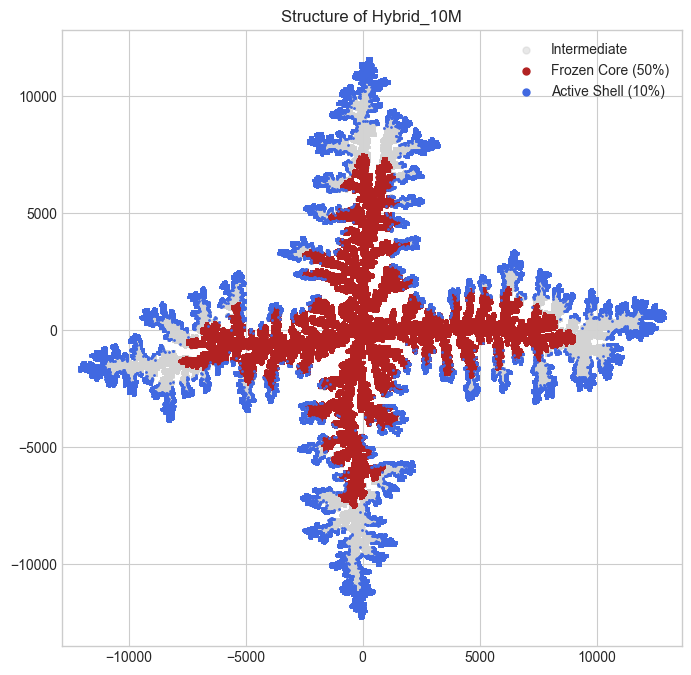

Model                | Core D     | Shell D    | Diff      
------------------------------------------------------------
Lattice_1M           | 1.6423     | 1.1759      | -0.4664
Lattice_10M          | 1.6712     | 1.2389      | -0.4323
OffLattice_1M        | 1.6490     | 1.1711      | -0.4779
OffLattice_10M       | 1.6674     | 1.2512      | -0.4162
Hybrid_1M            | 1.6554     | 1.1507      | -0.5047
Hybrid_10M           | 1.6701     | 1.2384      | -0.4317


In [12]:
def analyse_core_shell_robust(samples_dict):
    """
    Runs the Frozen Core vs Active Shell analysis on all loaded samples.
    """
    results_list = []
    
    print(f"{'Model':<20} | {'Core D':<10} | {'Shell D':<10} | {'Diff':<10}")
    print("-" * 60)
    
    for name, coords in samples_dict.items():
        N = len(coords)
        if N < 5000:
            print(f"Skipping {name}: Too small (N={N})")
            continue
            
        # 1. Slice
        core_coords = coords[:N//2]          # First 50%
        shell_coords = coords[int(N*0.9):]   # Last 10%
        
        # 2. Center the Shell (Critical!)
        # We shift the shell so its center of mass is at (0,0)
        shell_centered = shell_coords - np.mean(shell_coords, axis=0)
        
        # 3. Calculate Dimensions
        # Core
        sc, cc = calculate_box_counts(core_coords)
        # Filter for valid log values
        valid_c = (cc > 0)
        res_core = linregress(np.log(1/sc[valid_c]), np.log(cc[valid_c]))
        d_core = res_core.slope
        
        # Shell
        ss, cs = calculate_box_counts(shell_centered)
        valid_s = (cs > 0)
        res_shell = linregress(np.log(1/ss[valid_s]), np.log(cs[valid_s]))
        d_shell = res_shell.slope
        
        # 4. Store & Print
        diff = d_shell - d_core
        print(f"{name:<20} | {d_core:.4f}     | {d_shell:.4f}      | {diff:+.4f}")
        
        results_list.append({
            'Model': name,
            'D_Core': d_core,
            'D_Shell': d_shell,
            'Difference': diff,
            'N_particles': N
        })
        
    return pd.DataFrame(results_list)

def visualise_core_shell_split(coords, title="Core vs Shell"):
    """
    Visual sanity check: Plots the cluster colored by region.
    """
    N = len(coords)
    
    # Indices
    idx_core = int(N * 0.5)
    idx_shell = int(N * 0.9)
    
    plt.figure(figsize=(8, 8))
    
    # Plot Intermediate (Gray) - The "Middle History"
    plt.scatter(coords[idx_core:idx_shell, 0], coords[idx_core:idx_shell, 1], 
                c='lightgray', s=1, alpha=0.5, label='Intermediate')
    
    # Plot Core (Red)
    plt.scatter(coords[:idx_core, 0], coords[:idx_core, 1], 
                c='firebrick', s=1, label=f'Frozen Core (50%)')
    
    # Plot Shell (Blue)
    plt.scatter(coords[idx_shell:, 0], coords[idx_shell:, 1], 
                c='royalblue', s=1, label=f'Active Shell (10%)')
    
    plt.axis('equal')
    plt.legend(markerscale=5)
    plt.title(title)
    plt.show()

# --- EXECUTION ---

# 1. Run the visual check on one sample (e.g. the last one in the loop)
last_key = list(samples.keys())[-1]
visualise_core_shell_split(samples[last_key], title=f"Structure of {last_key}")

# 2. Run the numerical analysis
df_core_shell = analyse_core_shell_robust(samples)